In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Load dữ liệu từ Buổi 4 (đã có Risk Score)
df = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_survival.csv')

print(f"Data Loaded: {df.shape}")
df.head()

Data Loaded: (79949, 16)


,id,full_name,created_date,last_active_date,Customer_Segment_RFM,occupation,CLV_12_months,CLV_Segment,Churn_Prob,Survival_Risk_Score,T_months,E,exit,age,balance,Recency_Days
0,1,Đặng Văn Vũ,2025-02-27,2025-04-03,Loyal/Active Users,Chủ Doanh nghiệp nhỏ,8.294699e+05,Mid Value,0.000226,0.054347,1.166667,0,False,55,177306004,90
1,2,Bùi Hữu Phúc,2021-07-29,2025-05-14,Loyal/Active Users,Nội trợ/Sinh viên,9.998768e+04,Low Value,0.665092,3.687141,46.166667,0,False,45,1927416,49
2,3,Lê Văn Mai,2021-03-03,2021-09-10,Churned (Inactive),Chủ Doanh nghiệp nhỏ,5.317629e+01,Low Value,0.000541,0.034146,6.366667,0,False,44,304931745,1391
3,4,Dương Trần Nhiên,2022-02-12,2025-03-04,VIP At Risk,Chủ Doanh nghiệp nhỏ,2.525261e+06,High Value,0.008213,0.507754,37.200000,0,False,44,50615501,120
4,5,Dương Thu Linh,2022-07-24,2022-08-06,Churned (Inactive),Giáo viên/Giảng viên,3.084639e+03,Low Value,0.331101,2.545657,0.433333,0,False,77,40532432,1061


In [2]:
# 1. Giả lập nhóm Treatment (Được nhận Voucher) và Control (Không nhận gì)
np.random.seed(42)
# 50% khách hàng ngẫu nhiên được chọn vào nhóm Treatment
df['is_treated'] = np.random.binomial(n=1, p=0.5, size=len(df))

# 2. Giả lập hành vi phản hồi (Response Simulation)
# Quy tắc giả định:
# - Khách hàng có Survival_Risk cao VÀ CLV cao -> Rất thích Voucher (Persuadables)
# - Khách hàng có Risk thấp -> Dù có Voucher hay không vẫn ở lại (Sure Things)
# - Khách hàng quá tiêu cực -> Có voucher vẫn đi (Lost Causes)

# Tạo nhiễu ngẫu nhiên
noise = np.random.normal(0, 0.1, len(df))

# Công thức giả định xác suất Retention (Ở lại):
# Base Retention = 1 - Churn_Prob (đã có từ Buổi 3)
base_retention = 1 - df['Churn_Prob']

# Hiệu quả của Voucher (Uplift Effect):
# Giả sử Voucher tăng khả năng ở lại thêm 20-40% cho nhóm Risk cao
uplift_effect = 0.3 * df['Survival_Risk_Score'] * df['is_treated']

# Xác suất ở lại thực tế (đã cộng tác động của voucher + nhiễu)
prob_stay = base_retention + uplift_effect + noise
prob_stay = np.clip(prob_stay, 0, 1) # Giới hạn trong khoảng [0, 1]

# Tạo nhãn kết quả cuối cùng: 1 (Ở lại/Success), 0 (Rời bỏ/Fail)
df['conversion'] = np.random.binomial(n=1, p=prob_stay)

print("--- Kết quả chiến dịch giả lập ---")
print(df.groupby('is_treated')['conversion'].mean())
print("(Nếu conversion nhóm 1 > nhóm 0 thì chiến dịch có hiệu quả chung)")

--- Kết quả chiến dịch giả lập ---
is_treated
0    0.620872
1    0.981080
Name: conversion, dtype: float64
(Nếu conversion nhóm 1 > nhóm 0 thì chiến dịch có hiệu quả chung)


In [4]:
missing_cols = ['credit_sco', 'nums_service']

# Kiểm tra xem cột nào chưa có trong df
cols_to_restore = [col for col in missing_cols if col not in df.columns]

if cols_to_restore:
    print(f"⚠️ Phát hiện thiếu cột: {cols_to_restore}. Đang khôi phục...")
    try:
        # Load file gốc
        df_origin = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\bank_churn_dataset_80k.csv')
        
        # Chỉ lấy cột id và các cột cần khôi phục
        subset = df_origin[['id'] + cols_to_restore]
        
        # Merge vào df hiện tại
        df = df.merge(subset, on='id', how='left')
        print("✅ Đã khôi phục thành công các cột thiếu!")
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file gốc 'bank_churn_dataset_80k.csv'")
else:
    print("✅ Dữ liệu đã đầy đủ các cột cần thiết.")

⚠️ Phát hiện thiếu cột: ['credit_sco', 'nums_service']. Đang khôi phục...
✅ Đã khôi phục thành công các cột thiếu!


In [5]:
# Features dùng để dự đoán
features = [
    'Recency_Days', 'age', 'balance', 'credit_sco', 
    'nums_service', 'Survival_Risk_Score', 'CLV_12_months'
]

# Chia tách dữ liệu theo nhóm Treatment/Control
df_control = df[df['is_treated'] == 0]
df_treated = df[df['is_treated'] == 1]

# 1. Train Model Control (Dự đoán khả năng ở lại tự nhiên)
model_control = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_control.fit(df_control[features], df_control['conversion'])

# 2. Train Model Treatment (Dự đoán khả năng ở lại khi có Voucher)
model_treated = lgb.LGBMClassifier(random_state=42, verbose=-1)
model_treated.fit(df_treated[features], df_treated['conversion'])

print("Đã train xong 2 model T-Learner!")

Đã train xong 2 model T-Learner!


In [6]:
# Dự báo cho TOÀN BỘ khách hàng (Counterfactual Inference)

# Giả sử tất cả mọi người KHÔNG được nhận Voucher -> Họ sẽ thế nào?
prob_control = model_control.predict_proba(df[features])[:, 1]

# Giả sử tất cả mọi người ĐƯỢC nhận Voucher -> Họ sẽ thế nào?
prob_treated = model_treated.predict_proba(df[features])[:, 1]

# Tính Uplift Score (Hiệu quả gia tăng)
df['Uplift_Score'] = prob_treated - prob_control

# Xem thử kết quả
print(df[['full_name', 'Survival_Risk_Score', 'Uplift_Score']].head())

          full_name  Survival_Risk_Score  Uplift_Score
0       Đặng Văn Vũ             0.054347      0.042697
1      Bùi Hữu Phúc             3.687141      0.710224
2        Lê Văn Mai             0.034146      0.031224
3  Dương Trần Nhiên             0.507754      0.097951
4    Dương Thu Linh             2.545657      0.321248


--- Phân bố nhóm chiến lược ---
Uplift_Segment
Persuadables     61687
Sure Things      16432
Sleeping Dogs     1585
Lost Causes        245
Name: count, dtype: int64


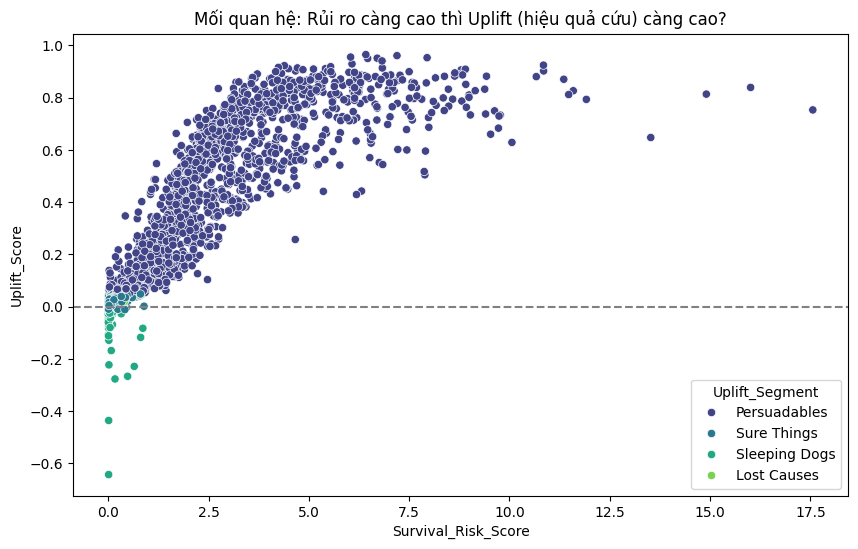

In [7]:
# Phân nhóm dựa trên Uplift Score
# Ngưỡng (Threshold) tùy chỉnh theo ngân sách. Ví dụ: Uplift > 5% mới đáng để tặng quà.

def segment_uplift(row):
    if row['Uplift_Score'] > 0.05: # Tăng khả năng ở lại > 5%
        return 'Persuadables' # (Cần cứu -> Ưu tiên số 1)
    elif row['Uplift_Score'] < -0.02: # Tác động tiêu cực (Tặng xong họ ghét bỏ đi nhanh hơn)
        return 'Sleeping Dogs' # (Đừng làm phiền)
    elif row['conversion'] == 1: # Uplift thấp nhưng vốn dĩ họ đã ở lại rồi
        return 'Sure Things' # (Không cần tặng vẫn ở)
    else:
        return 'Lost Causes' # (Tặng hay không cũng đi)

df['Uplift_Segment'] = df.apply(segment_uplift, axis=1)

print("--- Phân bố nhóm chiến lược ---")
print(df['Uplift_Segment'].value_counts())

# Vẽ biểu đồ quan hệ: Risk Score vs Uplift Score
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(2000), 
    x='Survival_Risk_Score', 
    y='Uplift_Score', 
    hue='Uplift_Segment',
    palette='viridis'
)
plt.axhline(0, color='grey', linestyle='--')
plt.title('Mối quan hệ: Rủi ro càng cao thì Uplift (hiệu quả cứu) càng cao?')
plt.show()

In [9]:
if 'gender' not in df.columns:
    print("⚠️ Đang khôi phục cột gender từ dữ liệu gốc...")
    try:
        # Load file gốc chỉ lấy id và gender
        df_origin = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\bank_churn_dataset_80k.csv')
        
        # Merge vào dataframe hiện tại
        df = df.merge(df_origin[['id', 'gender']], on='id', how='left')
        print("✅ Đã khôi phục thành công cột gender!")
    except FileNotFoundError:
        print("❌ Lỗi: Không tìm thấy file gốc bank_churn_dataset_80k.csv")

⚠️ Đang khôi phục cột gender từ dữ liệu gốc...
✅ Đã khôi phục thành công cột gender!


In [10]:
# Lưu tất cả các chỉ số quan trọng
final_cols = [
    'id', 'full_name', 'created_date', 'last_active_date',
    'occupation', 'age', 'gender', 'balance', # Thông tin cơ bản
    'Customer_Segment_RFM', # Buổi 1 (Quá khứ)
    'CLV_12_months', 'CLV_Segment', # Buổi 2 (Giá trị tương lai)
    'Churn_Prob', # Buổi 3 (Xác suất rời bỏ)
    'Survival_Risk_Score', 'T_months', # Buổi 4 (Thời gian & Rủi ro)
    'Uplift_Score', 'Uplift_Segment' # Buổi 5 (Phương án hành động)
]

df[final_cols].to_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\final_bank_customer_intelligence.csv', index=False)
print("✅ HOÀN TẤT PIPELINE! File 'final_bank_customer_intelligence.csv' đã sẵn sàng.")

✅ HOÀN TẤT PIPELINE! File 'final_bank_customer_intelligence.csv' đã sẵn sàng.
